# Preprocessing

> Scikit-learn transformers for preprocessing soil spectra

Each transformer follows the scikit-learn estimator API, with `fit`, `transform`, `fit_transform`, `get_params` and `set_params`. You can chain transformers in a `Pipeline` and tune their parameters with `GridSearchCV`. Every transformer takes a 2-D array `X` with one row per spectrum and one column per wavenumber, and returns a 2-D array.

In [ ]:
#| default_exp preprocessing

In [ ]:
#| hide
%load_ext autoreload
%autoreload 2

In [ ]:
#| export
from fastcore.all import *
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted
from scipy.signal import savgol_filter
from scipy.interpolate import make_interp_spline
from typing import Callable
import pywt

In [ ]:
from sklearn.pipeline import Pipeline
from scipy.stats import iqr
from soilspectfm.visualization import plot_spectra
from matplotlib import pyplot as plt
from soilspectfm.visualization import plot_spectra_comparison
from soilspectfm.datasets import load_toy_mir, load_toy_noisy_mir

The examples use the toy MIR dataset from `load_toy_mir`: 50 spectra measured from 600 to 4000 cm⁻¹, every 2 cm⁻¹.

In [ ]:
X, ws = load_toy_mir()

## Baseline corrections

In [ ]:
#| exports
class SNV(BaseEstimator, TransformerMixin):
    "Center and scale each spectrum independently (Standard Normal Variate)"
    def __init__(self,
        center_func: Callable=np.mean, # Function to center the data
        scale_func: Callable=np.std, # Function to scale the data
        eps: float=1e-10 # Small value to avoid division by zero
    ):
        store_attr()
    def fit(self, X, y=None): return self
    def transform(self,
        X: np.ndarray # Spectral data to be transformed
    ) -> np.ndarray: # Transformed spectra
        center = self.center_func(X, axis=1, keepdims=True)
        scale = self.scale_func(X - center, axis=1, keepdims=True) + self.eps
        return (X - center) / scale

`SNV` subtracts a center from each spectrum and divides by a spread, both computed across its wavenumbers. This removes baseline offsets and multiplicative scatter effects that differ between samples. `SNV` needs no fitted statistics: `fit` does nothing, and each spectrum is corrected on its own.

`center_func` and `scale_func` accept any function that takes numpy's `axis` and `keepdims` arguments. Common choices:

| Role | Function | Behavior |
|---|---|---|
| Center | `np.mean` (default) | Standard choice, sensitive to outliers |
| Center | `np.median` | Less affected by outliers, slower |
| Center | `np.min` | Makes all values non-negative, sensitive to noise |
| Center | `lambda x, **kw: 0` | No centering, keeps absolute values |
| Scale | `np.std` (default) | Standard choice, assumes a normal distribution |
| Scale | `lambda x, **kw: np.sqrt(np.mean(x**2, **kw))` | Root mean square, suits baseline variations |
| Scale | `scipy.stats.iqr` | Less affected by outliers and extreme peaks |
| Scale | `lambda x, **kw: np.max(x, **kw) - np.min(x, **kw)` | Range, keeps relative peak heights |
| Scale | `lambda x, **kw: np.median(np.abs(x - np.median(x, **kw)), **kw)` | Median absolute deviation, least affected by outliers, slower |

With the defaults, every corrected spectrum has mean 0 and standard deviation 1:

In [ ]:
X_tfm = SNV().fit_transform(X)
test_close(X_tfm.mean(axis=1), 0)
test_close(X_tfm.std(axis=1), 1)

A median center with an interquartile-range scale reduces the influence of strong peaks. Each corrected spectrum then has a median of 0:

In [ ]:
X_rob = SNV(center_func=np.median, scale_func=iqr).fit_transform(X)
test_close(np.median(X_rob, axis=1), 0)

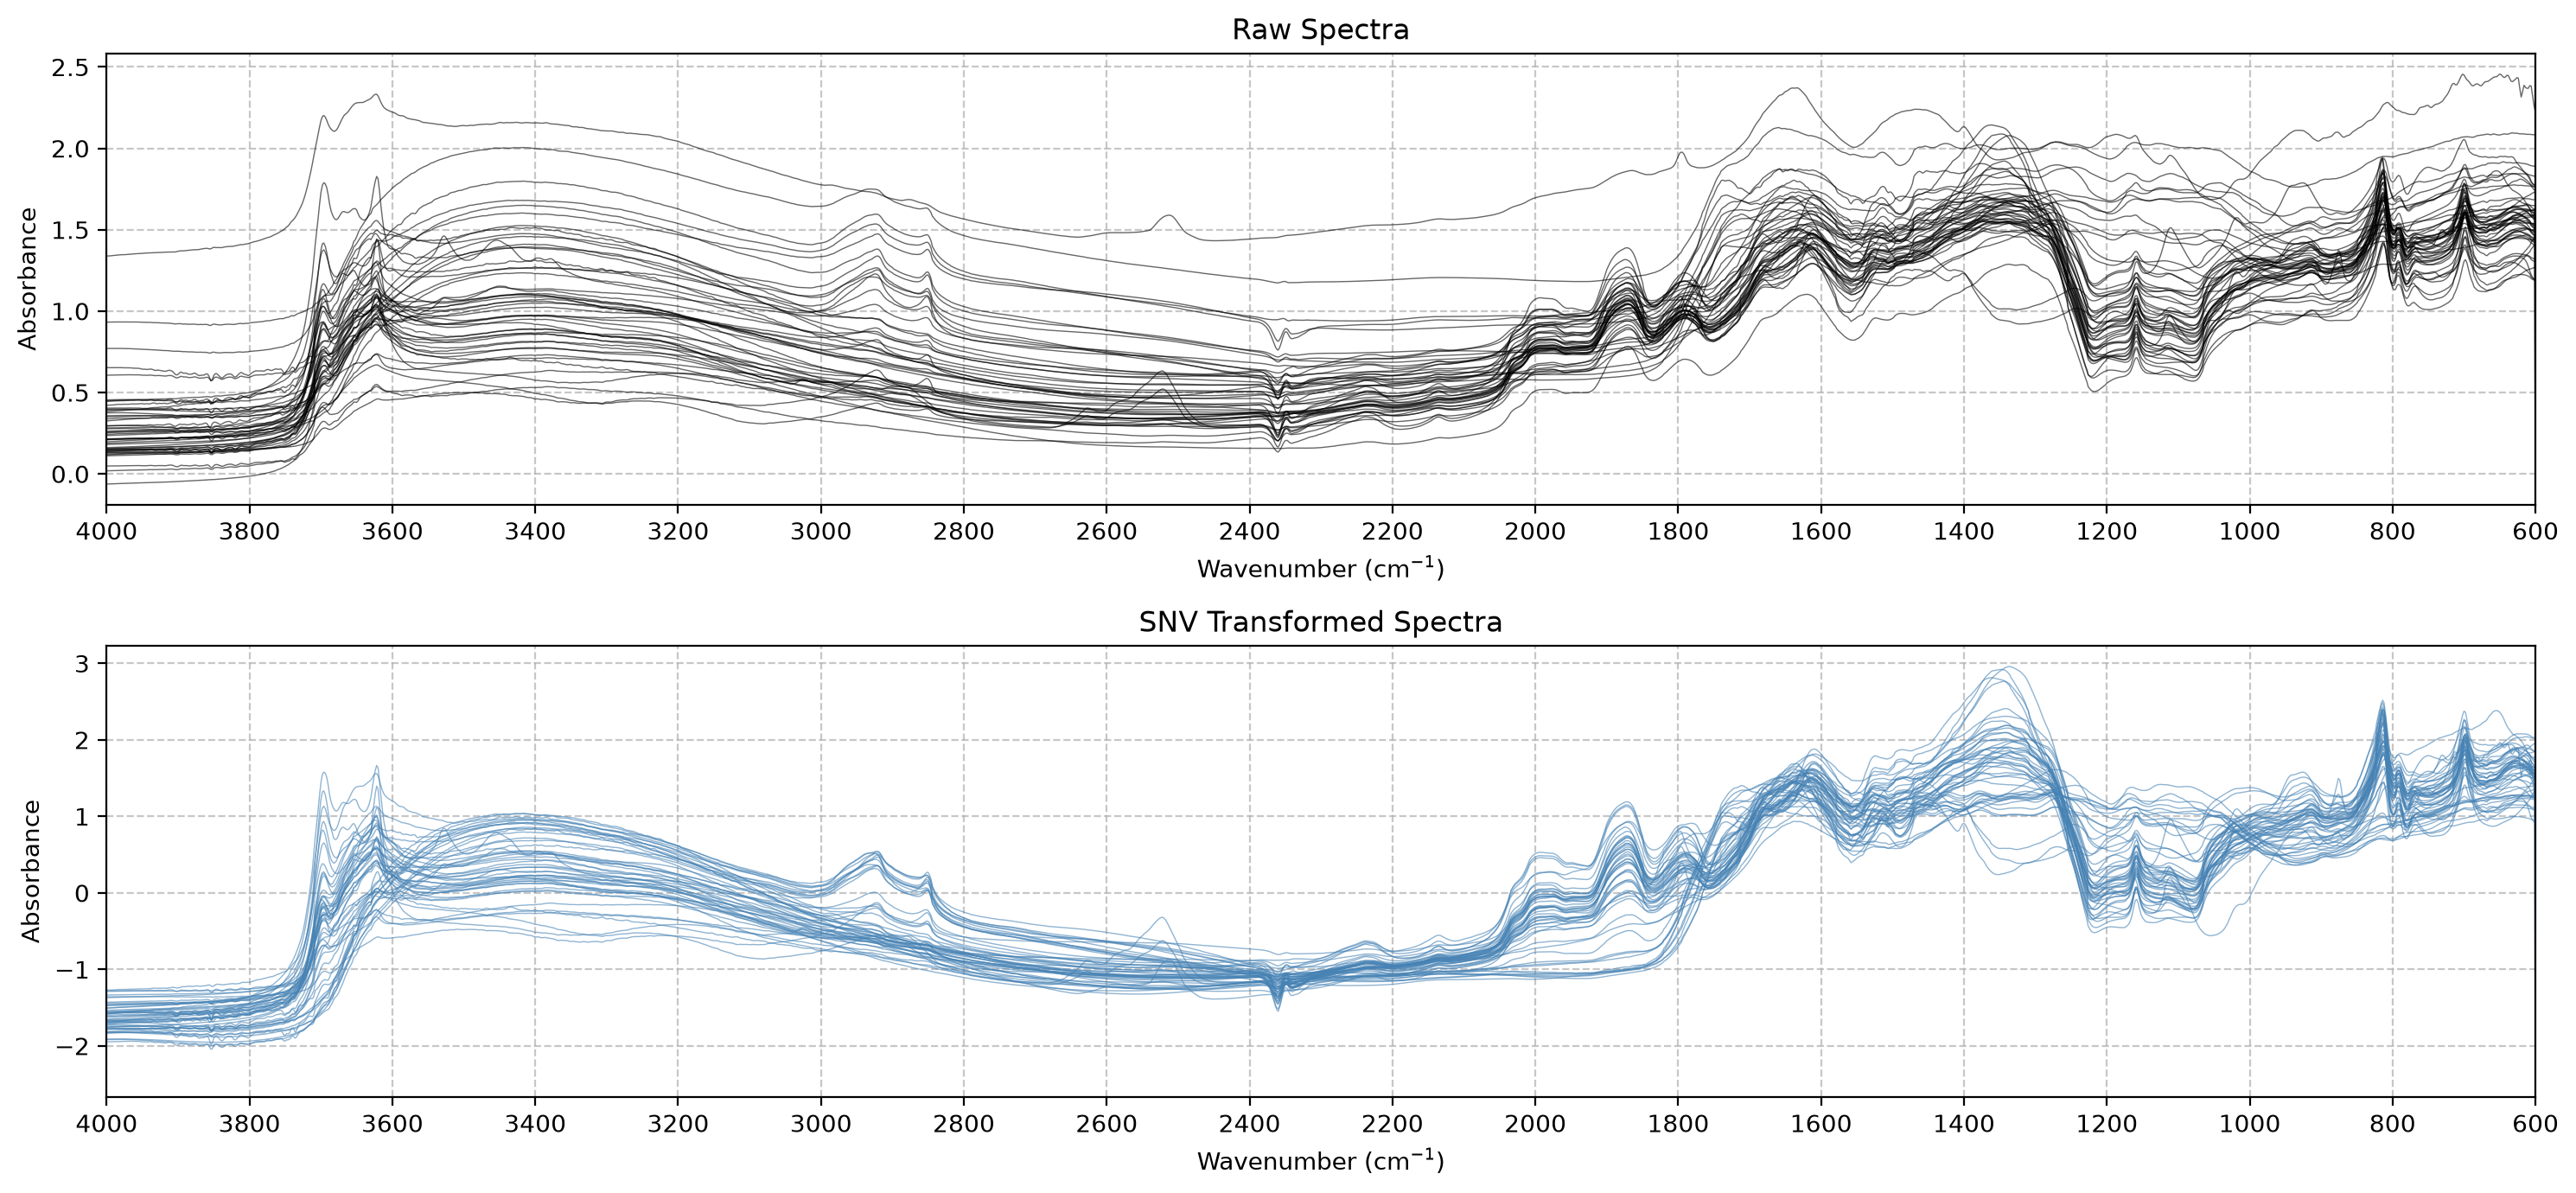

In [ ]:
plot_spectra_comparison(X, X_tfm, ws, raw_title='Raw Spectra', transformed_title='SNV Transformed Spectra');

In [ ]:
#| exports
class MSC(BaseEstimator, TransformerMixin):
    "Multiplicative Scatter Correction against a reference spectrum"
    def __init__(self,
        reference_method: Union[str, np.ndarray] = 'mean', # 'mean', 'median', or a reference spectrum
    ):
        store_attr()
        
    def _compute_reference(self, x: np.ndarray):
        "Compute reference spectrum from array using specified method"
        if isinstance(self.reference_method, str):
            if self.reference_method not in ('mean', 'median'): raise ValueError("reference_method must be 'mean', 'median' or a spectrum")
            return np.mean(x, axis=0) if self.reference_method == 'mean' else np.median(x, axis=0)
        return np.array(self.reference_method)
    
    def fit(self, X: np.ndarray, y=None):
        "Compute the reference spectrum"
        self.reference_ = self._compute_reference(X)
        return self
    
    def transform(self,
        X: np.ndarray # Spectral data to be transformed
    ) -> np.ndarray: # Transformed spectra
        "Apply MSC to the spectra"
        check_is_fitted(self)
        X = np.asarray(X)
        slope, intercept = np.polyfit(self.reference_, X.T, deg=1)
        return (X - intercept[:, None]) / slope[:, None]

`MSC` models each spectrum `x` as a linear function of a reference spectrum, `x ≈ a + b·reference`. It fits `a` and `b` by least squares, then returns `(x - a) / b`. This removes additive and multiplicative scatter effects relative to the reference.

`fit` sets `reference_` to the mean or median of the training spectra, or to the spectrum you pass as `reference_method`. `transform` corrects new spectra against that stored reference, so test spectra are corrected against the training reference. After correction, regressing each spectrum on the reference gives a slope of 1 and an intercept of 0:

In [ ]:
msc = MSC().fit(X)
X_msc = msc.transform(X)
slope, intercept = np.polyfit(msc.reference_, X_msc.T, deg=1)
test_close(slope, 1)
test_close(intercept, 0)

`reference_method='median'` uses the median spectrum as the reference, which is less sensitive to outlying samples:

In [ ]:
X_tfm = MSC(reference_method='median').fit_transform(X)

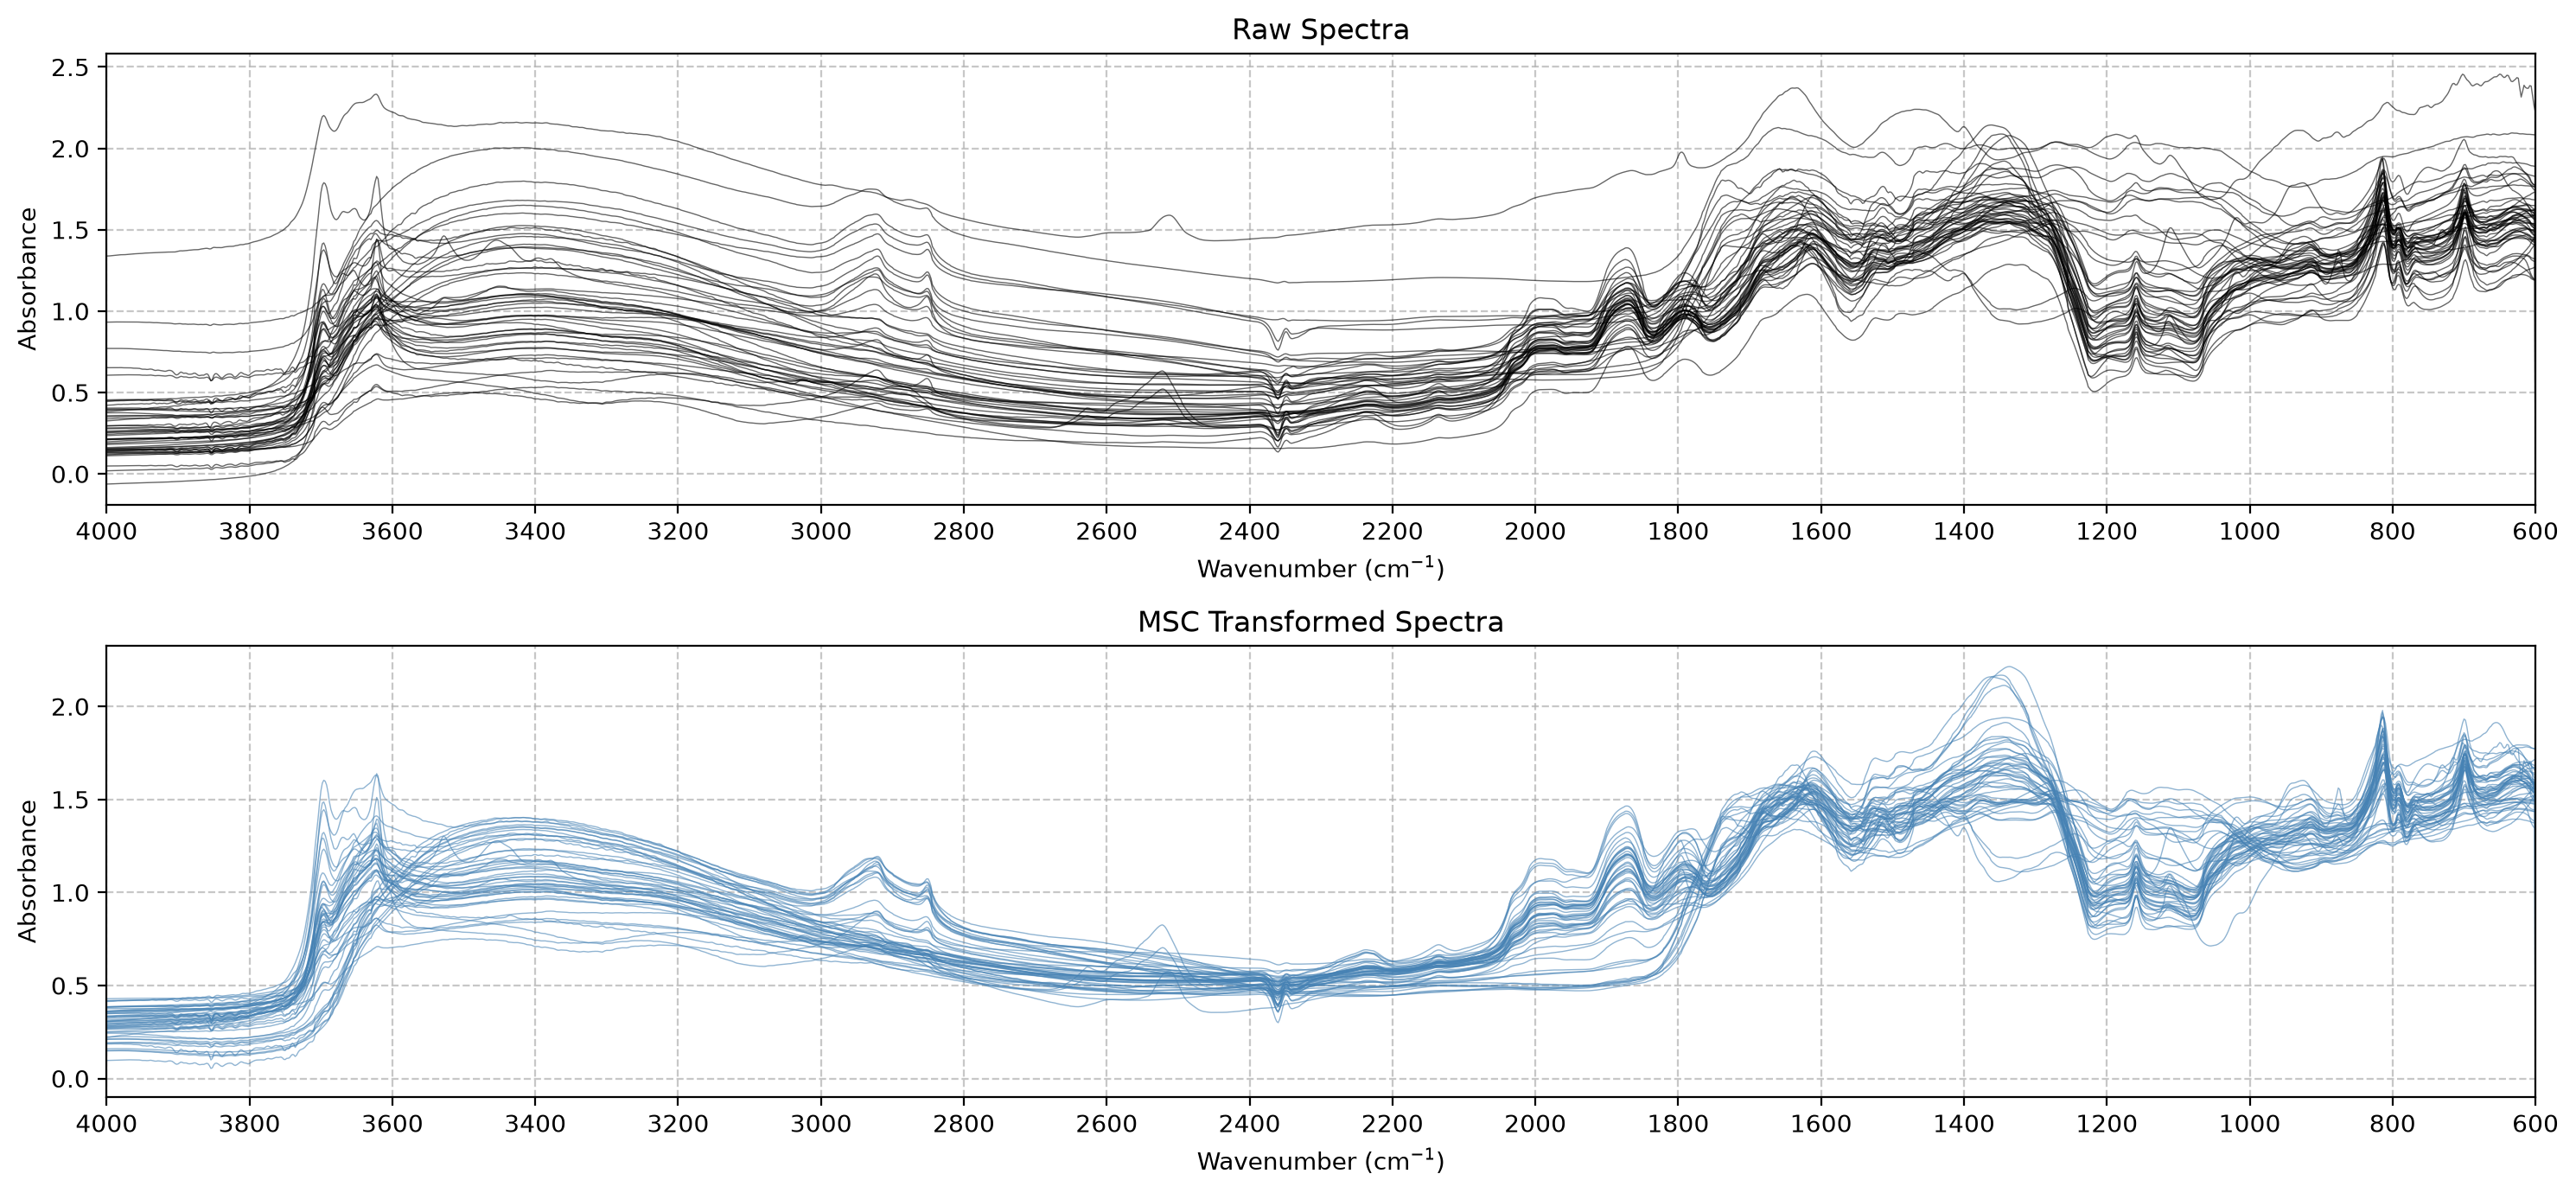

In [ ]:
plot_spectra_comparison(X, X_msc, ws, raw_title='Raw Spectra', transformed_title='MSC Transformed Spectra');

Asymmetric least squares (ALS) baseline correction is planned. References:

- https://eigenvector.com/wp-content/uploads/2020/01/RobustFittingtoBasisFunctionsIII.pdf
- https://nirpyresearch.com/two-methods-baseline-correction-spectral-data/
- https://diposit.ub.edu/dspace/bitstream/2445/188026/1/2014_IEEE_Adaptive_MarcoS_postprint.pdf

## Savitzky-Golay filter

In [ ]:
#| exports
class SavitzkyGolay(BaseEstimator, TransformerMixin):
    "Savitzky-Golay smoothing or derivative of each spectrum"
    def __init__(self,
        window_length:int=15, # Number of points in each filter window, odd
        polyorder:int=3, # Degree of the polynomial fitted in each window
        deriv:int=0 # Derivative order, 0 to smooth only
    ): store_attr()

    def fit(self,
        X:np.ndarray, # Spectra, one per row
        y:np.ndarray=None # Ignored
    ):
        "Check that the filter parameters are consistent"
        if self.window_length % 2 == 0: raise ValueError("window_length must be odd")
        if self.window_length <= self.polyorder: raise ValueError("window_length must be greater than polyorder")
        if self.deriv > self.polyorder: raise ValueError("deriv must be <= polyorder")
        return self

    def transform(self,
        X:np.ndarray # Spectra, one per row
    ) -> np.ndarray: # Filtered spectra
        "Filter each spectrum"
        return savgol_filter(np.asarray(X), self.window_length, self.polyorder, self.deriv)

`SavitzkyGolay` fits a polynomial of degree `polyorder` within each window of `window_length` points. With the default `deriv=0`, it replaces each point by the fitted value, which smooths the spectrum. With `deriv=1` or `deriv=2`, it returns the derivative of the fitted polynomial instead. Derivatives are taken per wavenumber step, not per cm⁻¹. `fit` checks that `window_length` is odd and greater than `polyorder`, and that `deriv` is at most `polyorder`.

Smoothing leaves a polynomial of degree up to `polyorder` unchanged:

In [ ]:
poly = ((ws / 1000) ** 3)[None]
test_close(SavitzkyGolay().fit_transform(poly), poly)

A first derivative removes constant baseline offsets, and a second derivative also removes linear baseline slopes. Adding a constant offset to every spectrum leaves the first derivative unchanged:

In [ ]:
sg1 = SavitzkyGolay(deriv=1)
test_close(sg1.fit_transform(X + 0.5), sg1.fit_transform(X))

Derivatives usually follow a scatter correction. In a `Pipeline`, `SNV` runs first, then `SavitzkyGolay`:

In [ ]:
pipe = Pipeline([('snv', SNV()), ('deriv', SavitzkyGolay(deriv=1))])
X_tfm = pipe.fit_transform(X)

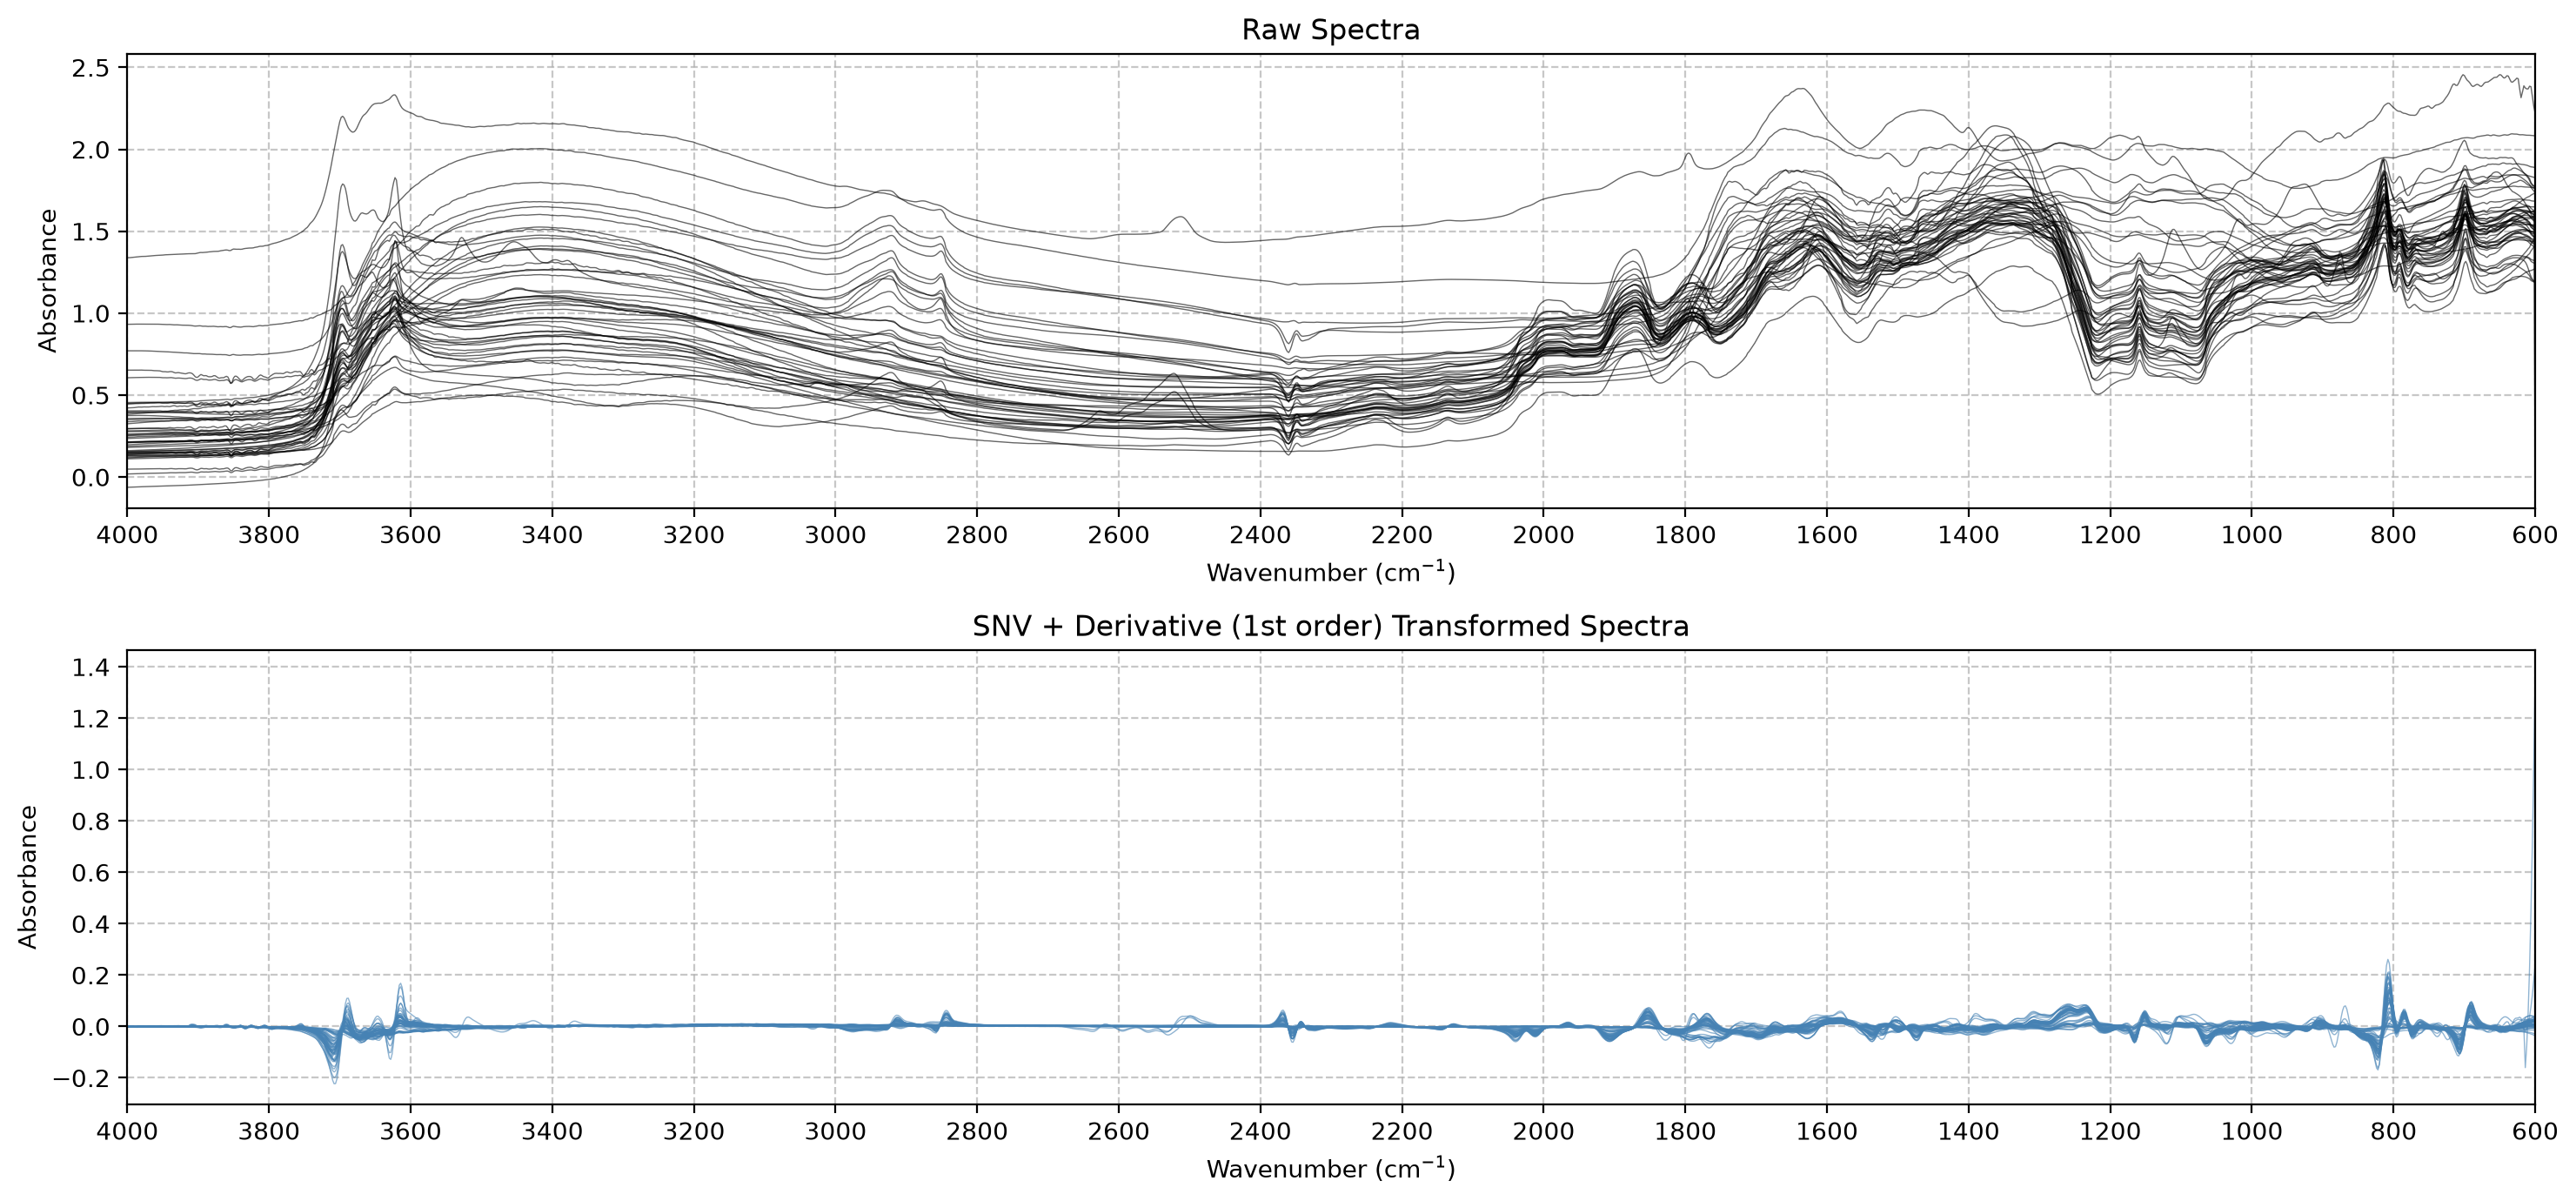

In [ ]:
plot_spectra_comparison(X, X_tfm, ws, raw_title='Raw Spectra', transformed_title='SNV + Derivative (1st order) Transformed Spectra');


## Smoothing

In [ ]:
#| exports
class WaveletDenoise(BaseEstimator, TransformerMixin):
    "Wavelet denoising of each spectrum"
    def __init__(self,
        wavelet:str='db6', # Wavelet to use for decomposition
        level:Optional[int]=None, # Decomposition level. If None, maximum level is used
        threshold_mode:str='soft' # Thresholding mode, 'soft' or 'hard'
    ):
        store_attr()
        
    def _denoise_single(self, spectrum):
        "Denoise a single spectrum"
        coeffs = pywt.wavedec(spectrum, self.wavelet, level=self.level_)
        
        detail_coeffs = np.concatenate(coeffs[1:])
        sigma = np.median(np.abs(detail_coeffs)) / 0.6745
        threshold = sigma * np.sqrt(2 * np.log(len(spectrum)))
        
        new_coeffs = list(coeffs)
        for i in range(1, len(coeffs)):
            new_coeffs[i] = pywt.threshold(coeffs[i], threshold * (1 / 2 ** ((self.level_ - i) / 2)), mode=self.threshold_mode)

        denoised = pywt.waverec(new_coeffs, self.wavelet)
        return denoised[:len(spectrum)]
    
    def fit(self, X, y=None):
        "Set `level_`: `level`, or the deepest level the spectrum length allows"
        self.level_ = ifnone(self.level, pywt.dwt_max_level(np.shape(X)[1], pywt.Wavelet(self.wavelet).dec_len))
        return self
    
    def transform(self, X):
        "Denoise each spectrum"
        X = np.asarray(X)
        X_denoised = np.zeros_like(X)
        for i in range(X.shape[0]): X_denoised[i] = self._denoise_single(X[i])
        return X_denoised

`WaveletDenoise` decomposes each spectrum with a discrete wavelet transform, shrinks the detail coefficients, and reconstructs the spectrum. The base threshold is the universal threshold `σ·√(2·ln n)`, where `n` is the spectrum length. `σ` is the median absolute value of all detail coefficients divided by 0.6745. For the `i`-th detail band, counted from the coarsest (`i = 1`) to the finest (`i = level_`), the threshold is multiplied by `2^(-(level_ - i)/2)`, so coarser bands get smaller thresholds. `threshold_mode` selects soft or hard thresholding, as in `pywt.threshold`.

The smoothing examples use `load_toy_noisy_mir`: 48 noisy MIR spectra from 599.9 to 3998.4 cm⁻¹, about every 1 cm⁻¹. From here on, `X` and `ws` refer to this dataset:

In [ ]:
X, ws, _ = load_toy_noisy_mir()

The difference between the raw and denoised spectra shows the noise that `WaveletDenoise` removes:

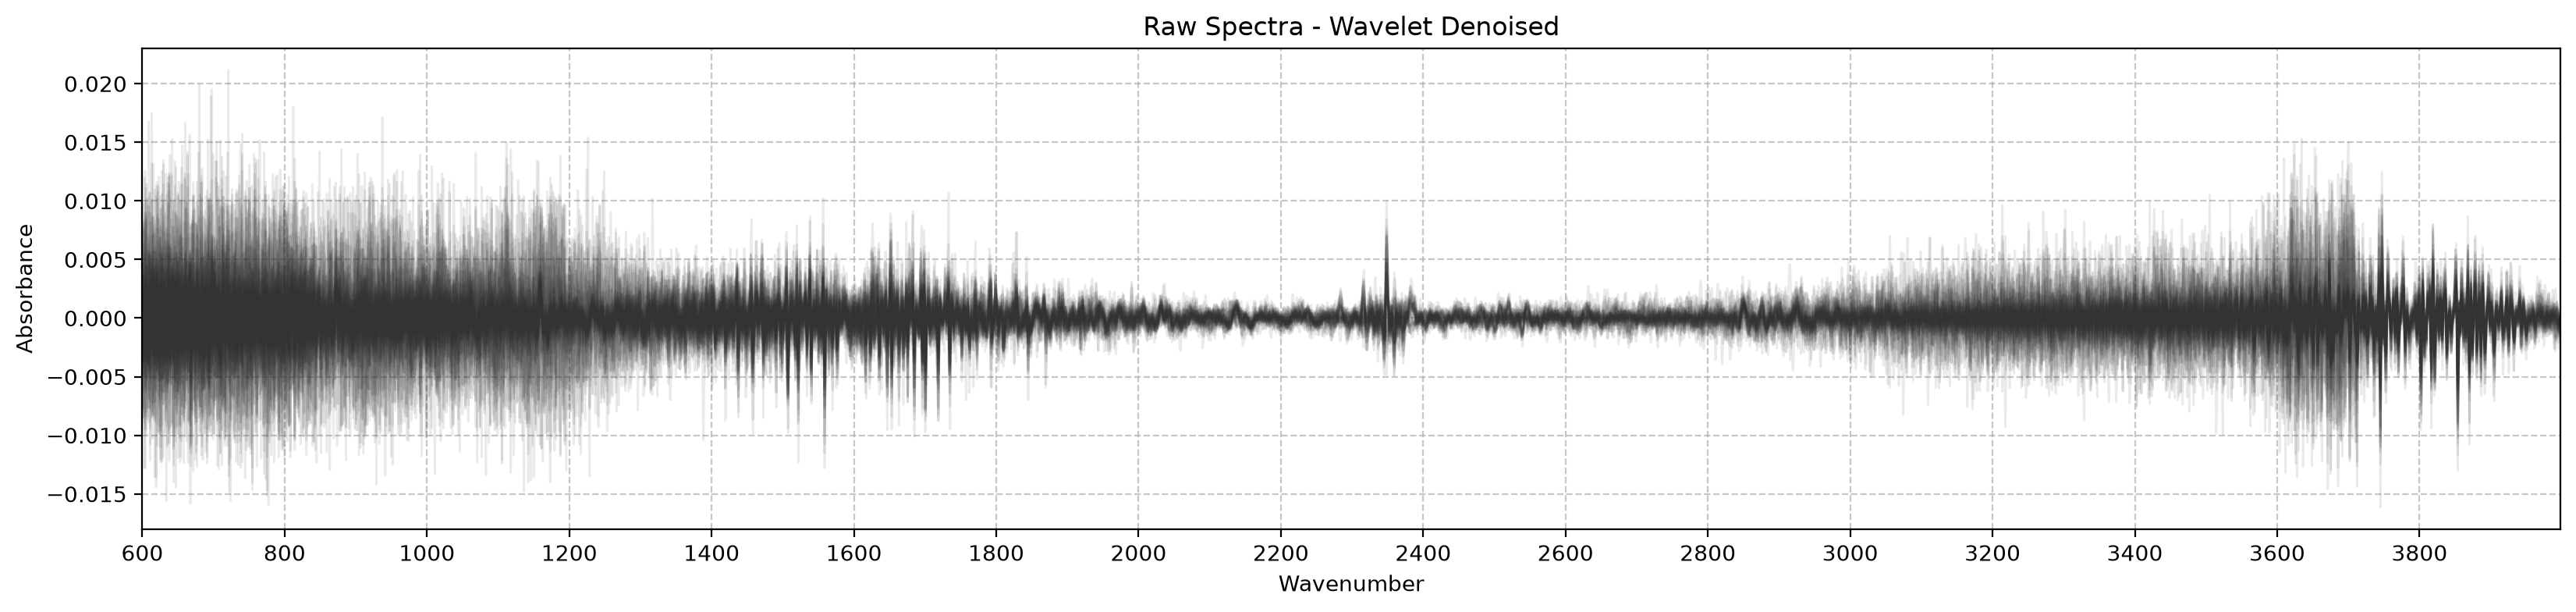

In [ ]:
X_denoised = WaveletDenoise(wavelet='db6', level=5, threshold_mode='soft').fit_transform(X)
plot_spectra(X - X_denoised, ws, alpha=0.1, title='Raw Spectra - Wavelet Denoised');

With the default `level=None`, `fit` sets `level_` to the deepest decomposition level that the spectrum length allows:

In [ ]:
wd = WaveletDenoise().fit(X)
test_eq(wd.level_, pywt.dwt_max_level(X.shape[1], 'db6'))
wd.level_

8

`SavitzkyGolay` with its defaults also smooths the noisy spectra:

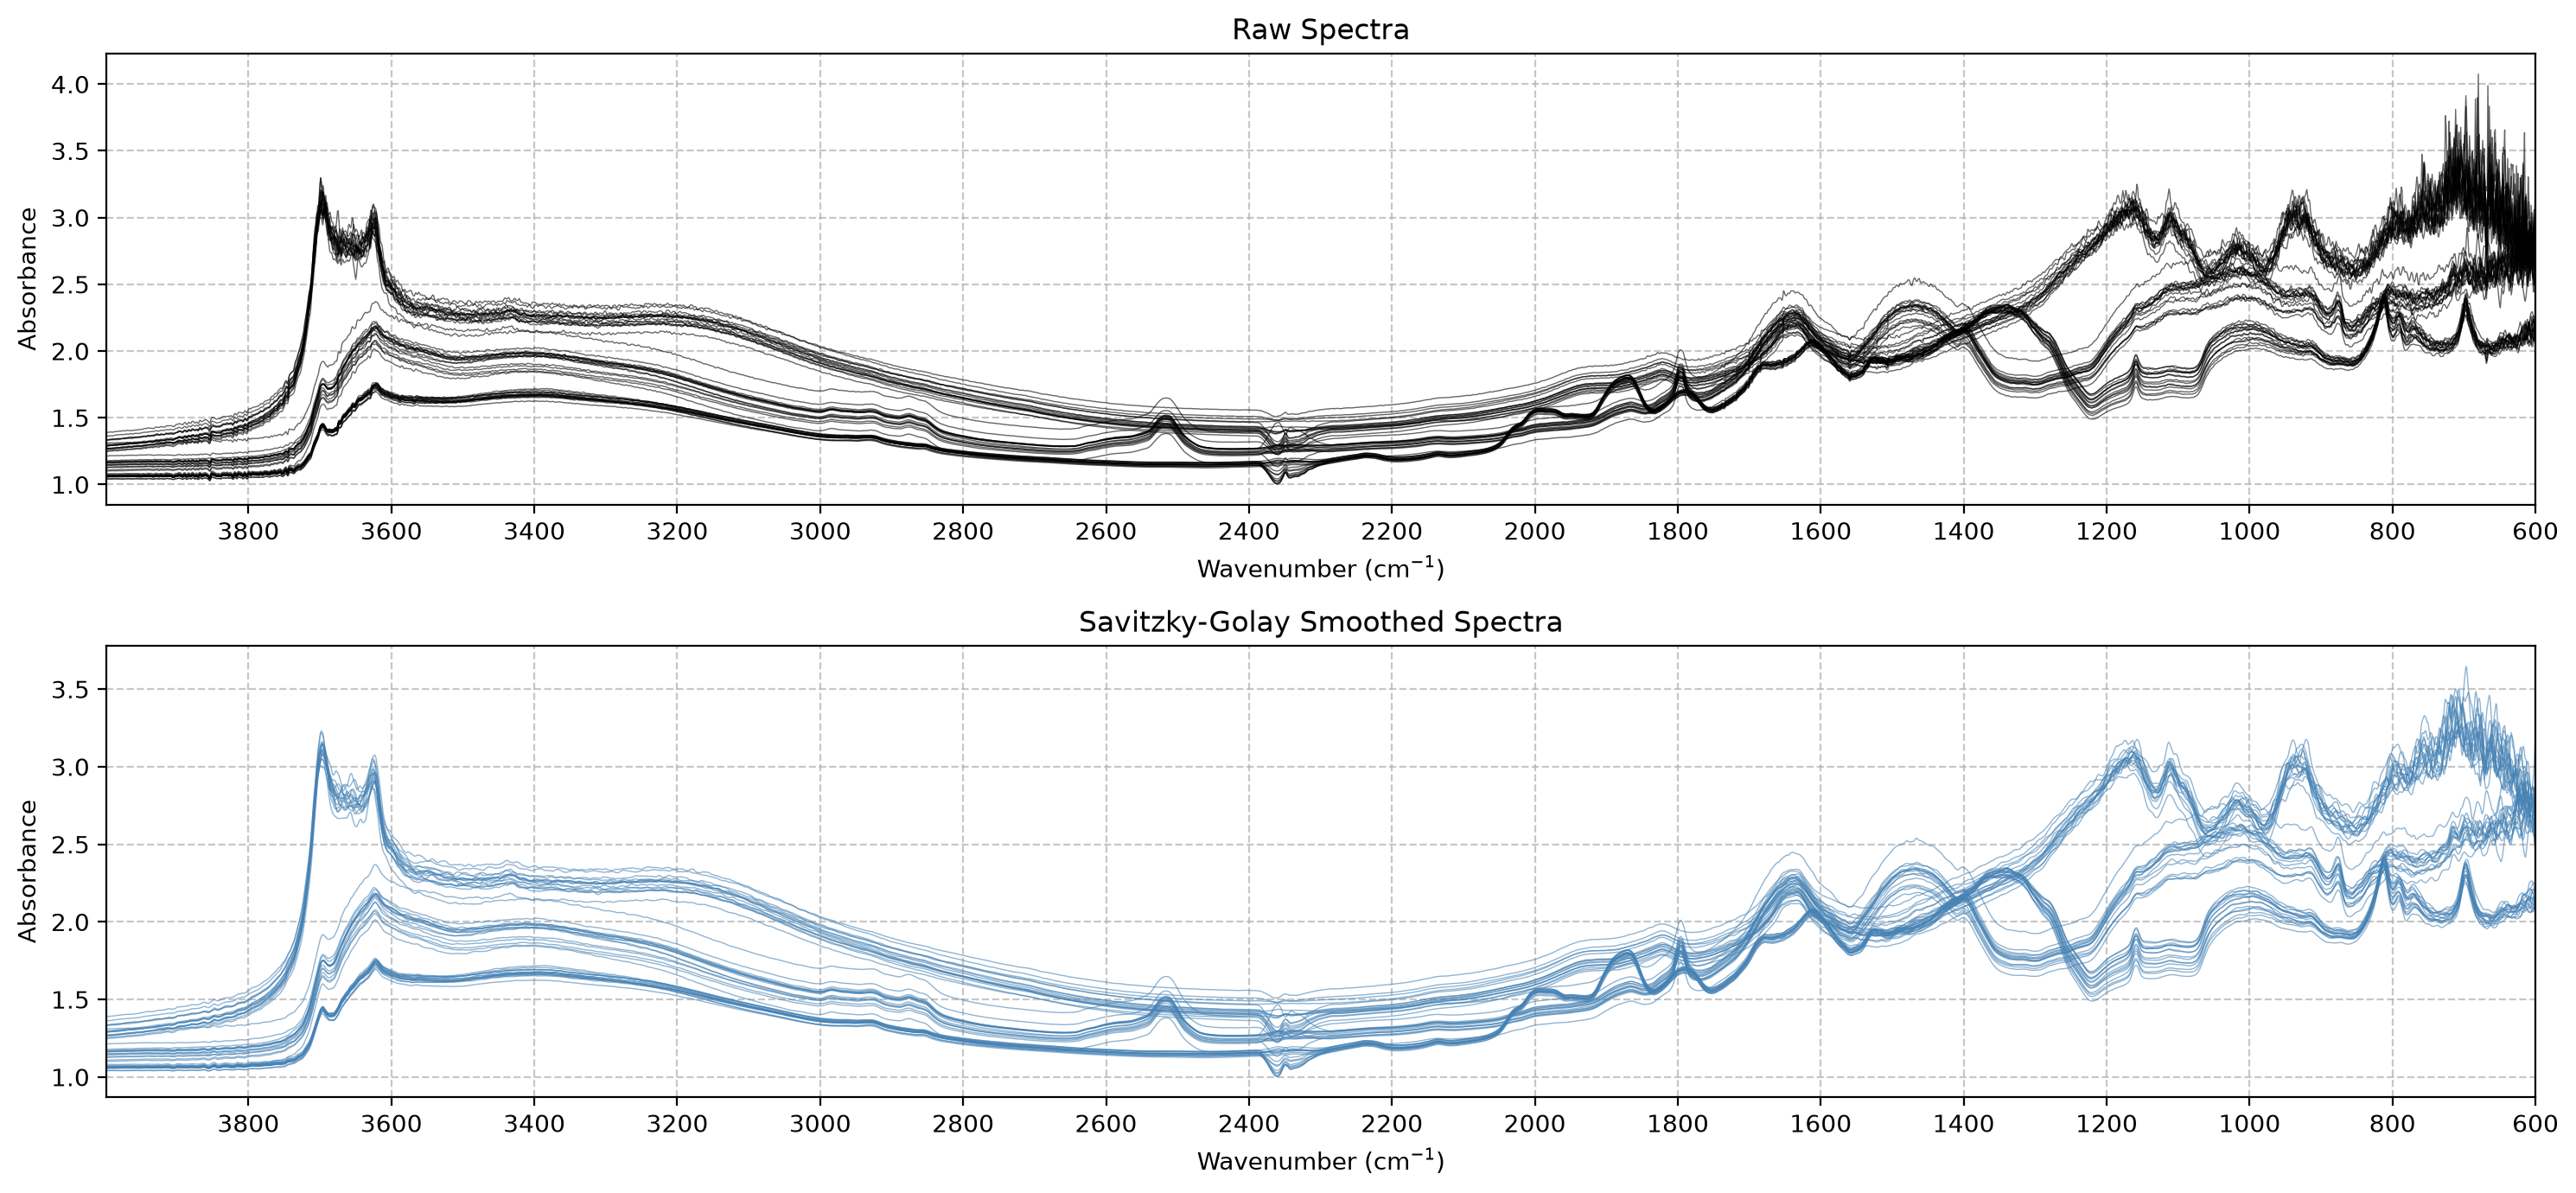

In [ ]:
X_smoothed = SavitzkyGolay().fit_transform(X)
plot_spectra_comparison(X, X_smoothed, ws, raw_title='Raw Spectra', transformed_title='Savitzky-Golay Smoothed Spectra');

## Other transformations

In [ ]:
#| exports
class ToAbsorbance(BaseEstimator, TransformerMixin):
    "Convert reflectance to absorbance, `-log10(R)`"
    def __init__(self,
        eps: float=1e-5 # Small value to avoid log(0)
    ): self.eps = eps
    def fit(self, X, y=None): return self
    def transform(self, X, y=None): return -np.log10(np.clip(X, self.eps, 1))

`ToAbsorbance` converts reflectance `R` to absorbance `A = -log10(R)`. It first clips `R` to the range `[eps, 1]`, so zero or negative values don't produce infinities, and values above 1 give an absorbance of 0:

In [ ]:
test_close(ToAbsorbance().fit_transform(np.array([[1, 0.1, 0.01]])), [[0, 1, 2]])

In [ ]:
#| exports
class Resample(BaseEstimator, TransformerMixin):
    "Resample spectra onto new x-axis points by spline interpolation"
    def __init__(self,
        source_x: np.ndarray, # Source x-axis points (wavenumbers or wavelengths)
        target_x: np.ndarray, # Target x-axis points (wavenumbers or wavelengths) for resampling
        interpolation_kind: str='cubic' # Spline kind: 'linear', 'quadratic' or 'cubic'
    ):
        store_attr()
        
    def fit(self,
        X: np.ndarray, # Spectral data to be resampled
        y: np.ndarray=None # Ignored
    ):
        "Check `X` against `source_x`, check `target_x` is in range, and sort `source_x`"
        n_cols, n_src = np.shape(X)[1], len(self.source_x)
        if n_cols != n_src: raise ValueError(f"X has {n_cols} columns but source_x has {n_src} points")
        self.order_ = np.argsort(self.source_x)
        lo, hi = np.asarray(self.source_x)[self.order_[[0, -1]]]
        if np.min(self.target_x) < lo or np.max(self.target_x) > hi:
            raise ValueError(f"target_x must lie within the source_x range [{lo}, {hi}]")
        return self
    
    def transform(self,
        X: np.ndarray # Spectral data to be resampled
    ):
        "Interpolate each spectrum at `target_x`"
        k = dict(linear=1, quadratic=2, cubic=3)[self.interpolation_kind]
        xs = np.asarray(self.source_x)[self.order_]
        return make_interp_spline(xs, np.asarray(X)[:, self.order_], k=k, axis=1)(self.target_x)

`Resample` interpolates each spectrum from `source_x` onto `target_x`, for example to put spectra from different instruments on one wavenumber grid. Here the noisy spectra, sampled about every 1 cm⁻¹, are resampled every 2 cm⁻¹:

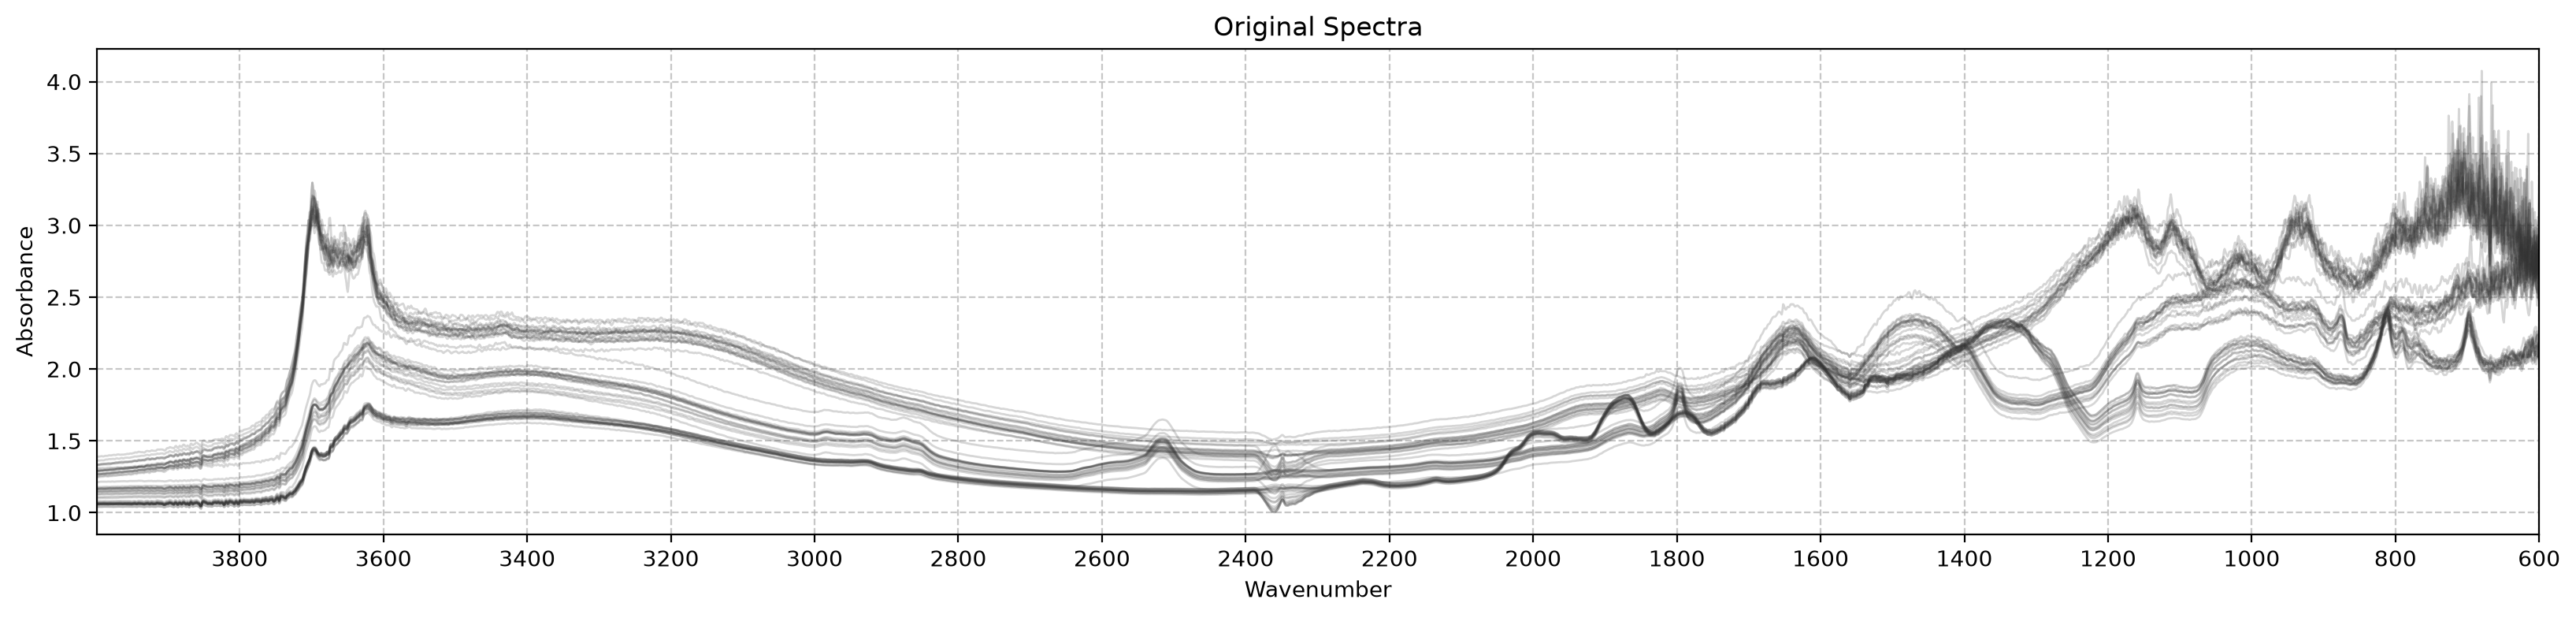

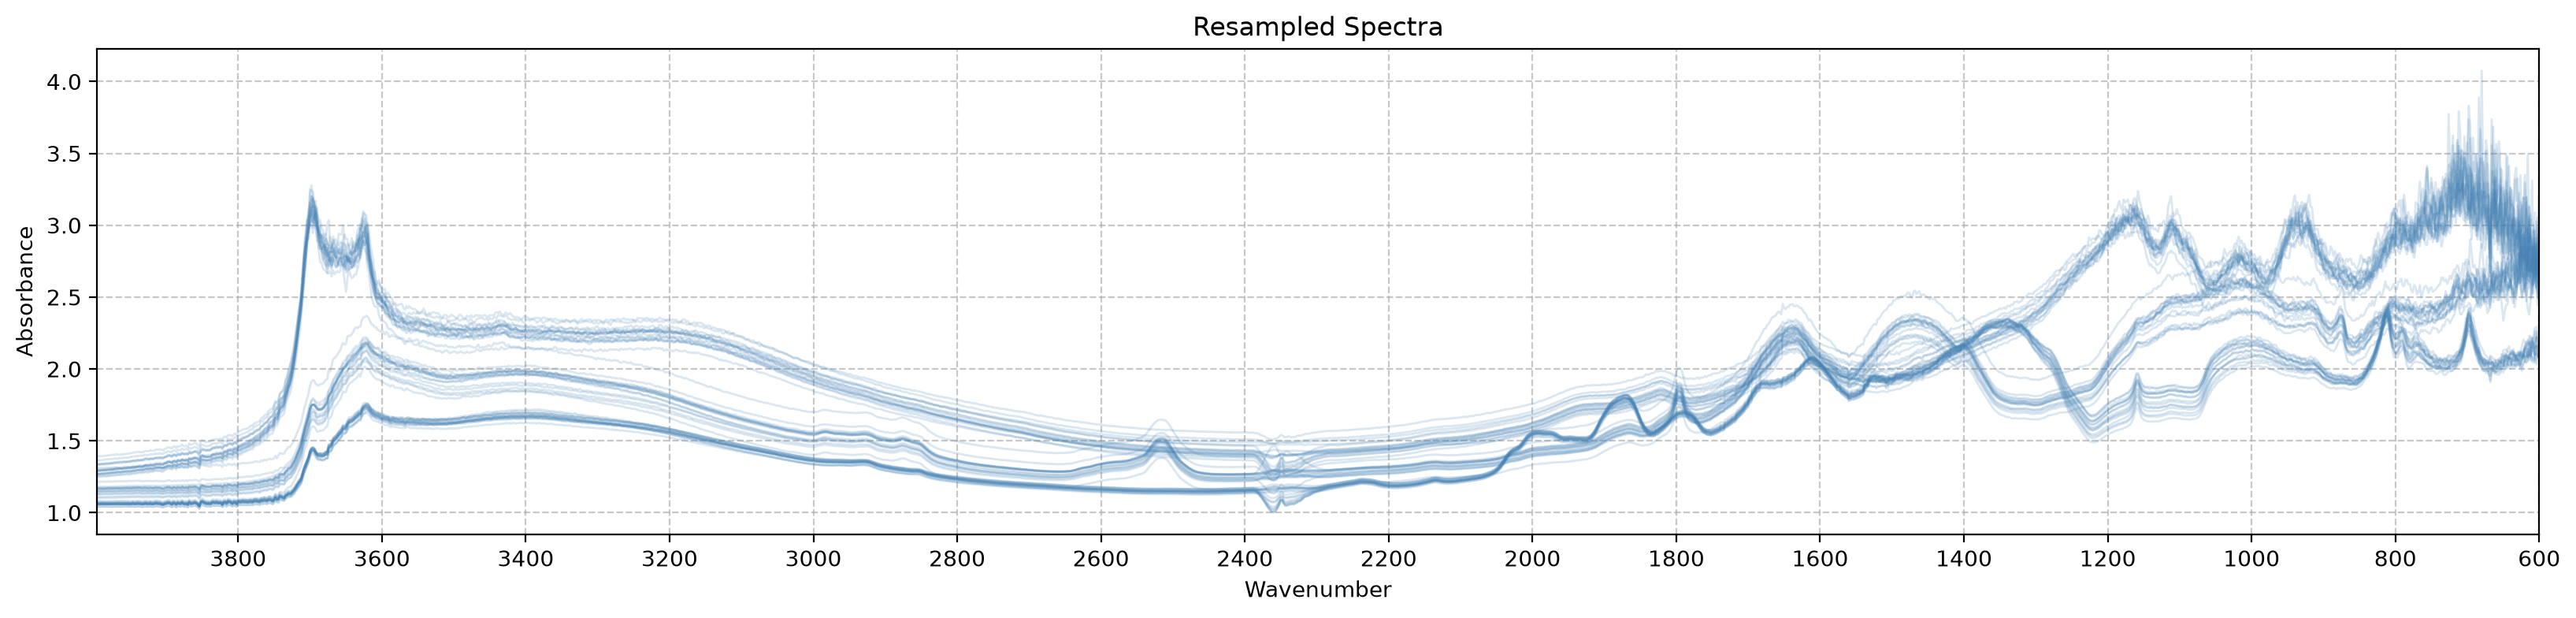

In [ ]:
new_ws = np.arange(600, 3998, 2)
X_resampled = Resample(source_x=ws, target_x=new_ws).fit_transform(X)
test_eq(X_resampled.shape, (len(X), len(new_ws)))
plot_spectra(X, ws, ascending=False, title='Original Spectra', alpha=0.2);
plot_spectra(X_resampled, new_ws, ascending=False, title='Resampled Spectra', alpha=0.2, color='steelblue');

`interpolation_kind` sets the spline degree: `'linear'`, `'quadratic'` or `'cubic'`. Linear resampling gives the same result as `np.interp`:

In [ ]:
X_lin = Resample(ws, new_ws, interpolation_kind='linear').fit_transform(X)
test_close(X_lin, np.array([np.interp(new_ws, ws, x) for x in X]))

`fit` raises a `ValueError` when `target_x` goes beyond the range of `source_x`, instead of extrapolating. The noisy spectra end at 3998.4 cm⁻¹, so a grid up to 4000 cm⁻¹ fails:

In [ ]:
test_fail(lambda: Resample(ws, np.arange(600, 4001, 2)).fit(X), contains='source_x range')

`source_x` can be in decreasing order, as some instruments export spectra from high to low wavenumbers. `fit` sorts it, and reorders the columns of `X` to match:

In [ ]:
test_close(Resample(ws[::-1], new_ws).fit_transform(X[:, ::-1]), X_resampled)

In [ ]:
#| exports
class Trim(BaseEstimator, TransformerMixin):
    "Keep the wavenumbers (or wavelengths) between `w_min` and `w_max`"
    def __init__(self,
        ws: np.ndarray, # Wavenumbers or wavelengths
        w_min: Optional[float]=None, # Minimum wavenumber or wavelength
        w_max: Optional[float]=None # Maximum wavenumber or wavelength
    ):
        store_attr()
        
    def fit(self,
        X: np.ndarray, # Spectra to be trimmed
        y: Optional[np.ndarray]=None # Ignored
    ):
        "Compute `mask_`, the columns whose wavenumber is inside the range"
        self.mask_ = (self.ws >= (-np.inf if self.w_min is None else self.w_min)) & \
                     (self.ws <= (np.inf if self.w_max is None else self.w_max))
        return self
    
    def transform(self, X: np.ndarray) -> np.ndarray:
        "Keep the columns inside the range"
        return X[:, self.mask_]
    
    def get_wavenumbers(self) -> np.ndarray:
        "Return the trimmed wavenumbers"
        return self.ws[self.mask_]

`Trim` keeps the wavenumbers between `w_min` and `w_max`, inclusive. A bound left as `None` leaves that side open. `get_wavenumbers` returns the kept wavenumbers, to use as the x-axis of the trimmed spectra:

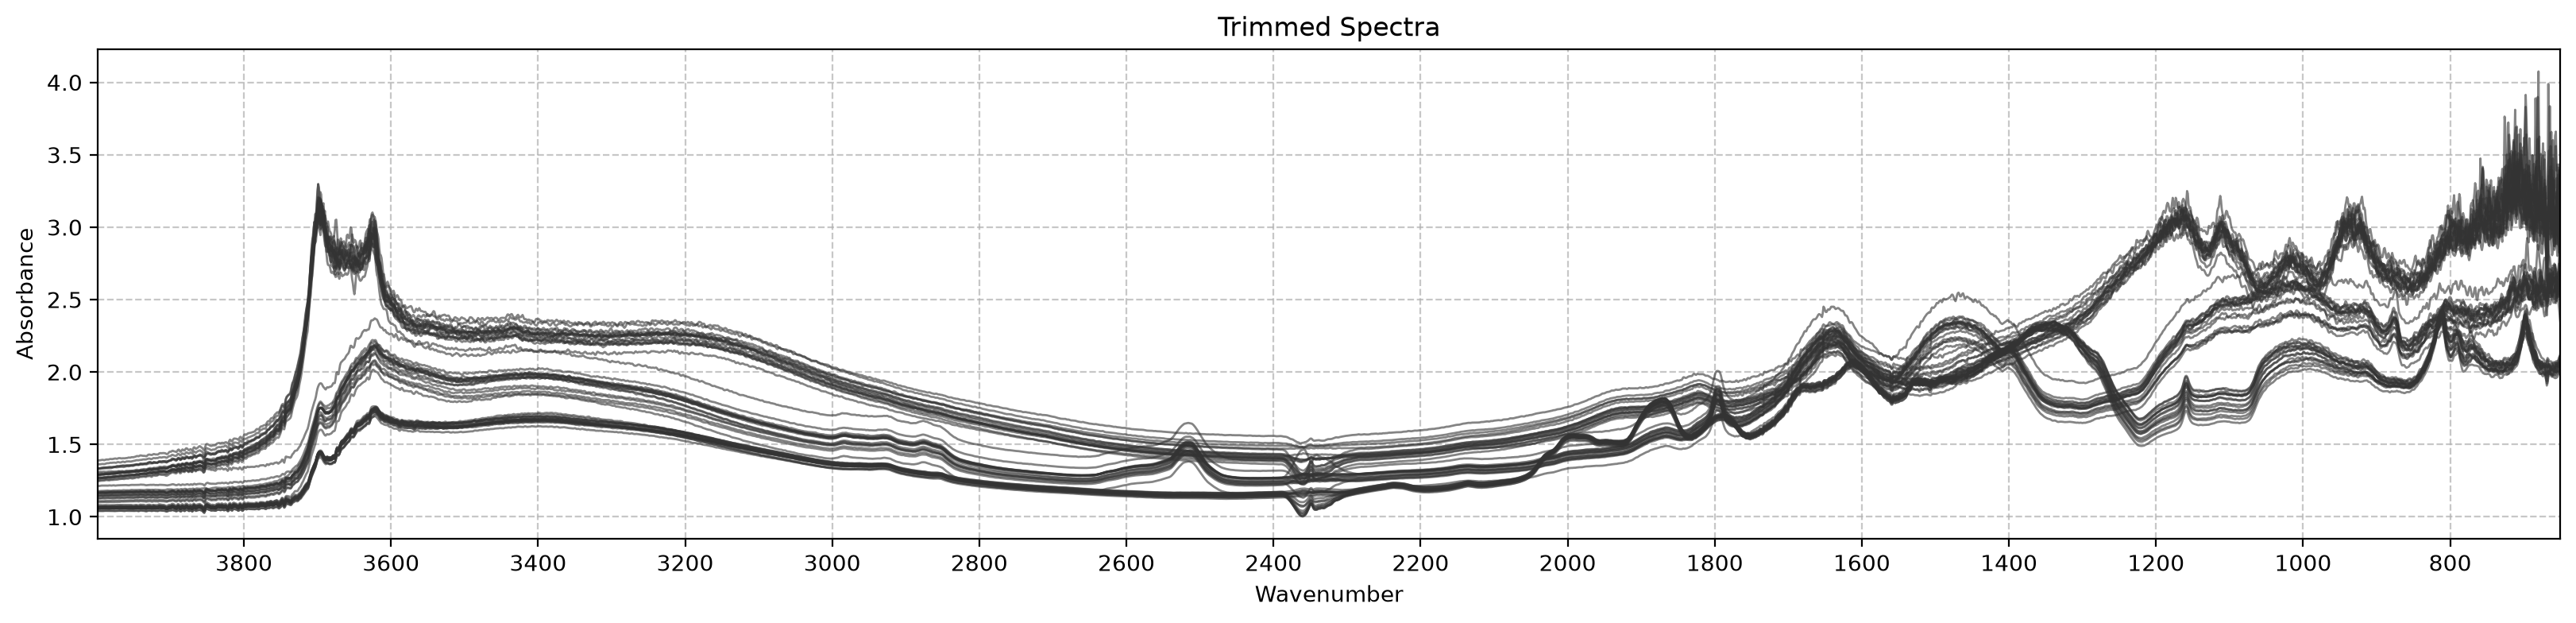

In [ ]:
trimmer = Trim(ws, w_min=650, w_max=4000)
X_trimmed = trimmer.fit_transform(X)
trimmed_ws = trimmer.get_wavenumbers()
assert trimmed_ws.min() >= 650 and trimmed_ws.max() <= 4000
plot_spectra(X_trimmed, trimmed_ws, title='Trimmed Spectra', ascending=False);